<a href="https://colab.research.google.com/github/io-uty/skt-bigdata-analysis/blob/main/05_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-최근접 이웃(K-Nearest Neighbor,KNN)
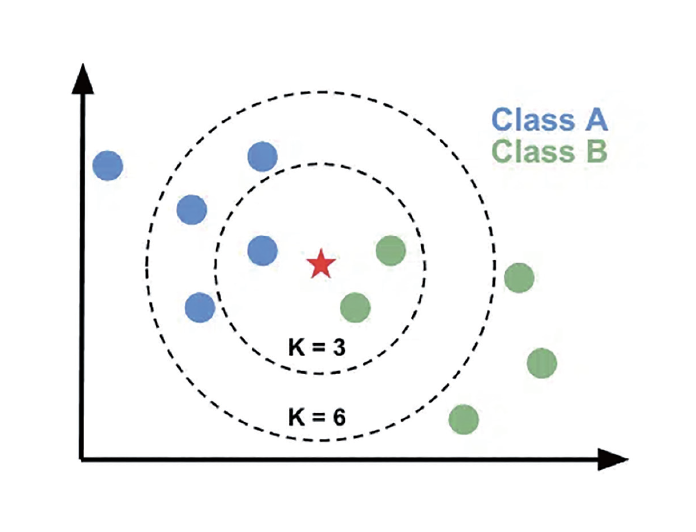

- seaborn에서 제공
- 펭귄 데이터셋은
  - 3종류 (Adelin, Chinstrap, Gentoo)펭귄의 부리길이, 날개 길이, 몸무게 등의 신체 치수를 측정한 톧계 데이터
  - https://github.com/MohamedR4dy/Penguin-in-Antarctica-EDA

### 데이터 구조 : 총 7개 변수로 구성

- species : 이 열은 펭귄 종을 나타내며, 턱끈펭귄, 아델리펭귄 또는 젠투펭귄일 수 있습니다.
- island : 펭귄이 관찰된 섬의 이름 - 드림 섬, 토르거센 섬, 비스코 섬 등이 있으며, 모두 남극 팔머 군도에 위치해 있습니다.
- culmen_length_mm : 밀리미터 단위로 측정된 폐맥 길이는 중요한 형태학적 특징입니다.
- culmen_depth_mm : 밀리미터 단위로 측정되는 융기 깊이는 융기 길이 측정값을 보완합니다.
- flipper_length_mm : 지느러미 길이(밀리미터) - 이 펭귄들이 수영하고 생존하는 데 도움이 되는 중요한 해부학적 특징입니다.
- body_mass_g : 몸무게는 그램 단위로 기록되어 펭귄의 신체 상태를 파악하는 데 도움이 됩니다.
- sex : 펭귄의 성별 분포에 대한 정보를 제공합니다.

- 주요 활용 사례 (시각화)
  - 수치형 데이터 간 관계 파악 또는 종별 차이 확인
  ---
  - sns.pairplot()
  - sns.histplot()
  - sns.scatterplot()

In [61]:
import numpy as np
import pandas as pd
import seaborn as sns

df = sns.load_dataset("penguins")
df.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [ ]:
print(df.shape) #전체 데이터 개수와 feature개수

(344, 7)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [62]:
df['species'].value_counts()
df.isnull().sum(axis=0)
df = df.dropna()
df.isnull().sum(axis=0)

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


- **결측치 확인**
  - Pandas 데이터프레임에서 각 열 별로 결측치(누락데이터, NaN)의 개수 합산
  - isnull()데이터의 각 셀이 결측치인지 검사하여 True(결측치) or False 값 반환
  - .sum(axis=0) 행 방향(위->아래)으로 값 합산
  - python에서 True(1) False(0)으로 처리, 결국 각 열의 결측치 총합이 된다

- 결측치가 포함된 행을 삭제


- **레이블 인코딩**
  - 머신러닝 알고리즘이 이해할 수 있도록
  - '사과, 바나나' 같은 문자열(범주형) 데이터를 숫자형으로 일괄 변환하는 데이터 전처리 기법

- **원핫 인코딩**
  - 0001, 0010, 0100, 1000
  -> bitmap index랑 비슷함

In [63]:
df['species'] = df['species'].map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2})
df['island'] = df['island'].map({'Biscoe':0, 'Dream':1, 'Torgersen':2})
df['sex'] = df['sex'].map({'Female':0, 'Male':1})

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.1,18.7,181.0,3750.0,1
1,0,2,39.5,17.4,186.0,3800.0,0
2,0,2,40.3,18.0,195.0,3250.0,0
4,0,2,36.7,19.3,193.0,3450.0,0
5,0,2,39.3,20.6,190.0,3650.0,1


- 시각화 : 산점도를 그려서 확인

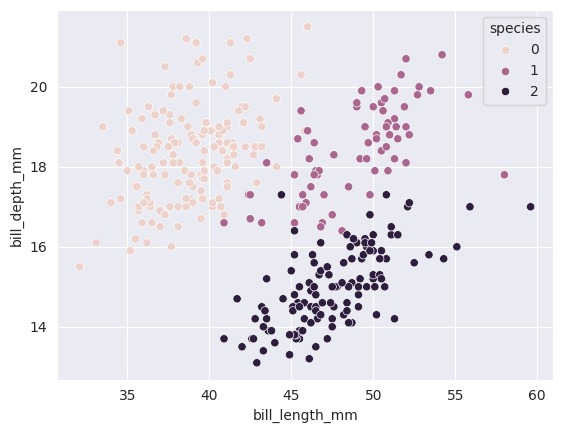

In [64]:
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

sns.scatterplot(x="bill_length_mm", y="bill_depth_mm",data=df, hue="species")
plt.show()

- feature와 label(타겟) 분리
  -> 지도학습을 제대로 수행하기 위해

> ML에서 Feature과 Label을 분리하는 핵심 이유는

- 지도학습 (Supervised Learning)의 메커니즘을 충족하고, 모델의 과적합을 방지하며, 새로운 데이터에 대한 예측력을 검증하기 위해

---
> 과적합(Overfitting,과대적합)
  : 머신러닝이나 딥러닝 모델이 학습 데이터에 너무 과하게 맞춰져서, 실제 예측이나 새로운 데이터(테스트 데이터)에서는 성능이 크게 떨어지는 현상


In [65]:
X = df.drop(['species'], axis=1)
y = df['species']
X.head()
# y.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,2,39.1,18.7,181.0,3750.0,1
1,2,39.5,17.4,186.0,3800.0,0
2,2,40.3,18.0,195.0,3250.0,0
4,2,36.7,19.3,193.0,3450.0,0
5,2,39.3,20.6,190.0,3650.0,1


> 테스트 데이터 분리

> **사이킷런(scikit-learn)**
- 파이썬 기반 대표적인 오픈소스 ML library
- 데이터전처리, 분류, regression, grouping등 다양한 ML작업에 필요한 도구와 알고리즘 제공

**train-test-split**
- ML Model을 학습, 평가하기 위해 전체 데이터를 학습용과 테스트용으로 무작위 분할
- 과적합 방지 : 학습에 사용하지 않은 완전 새로운 데이터로 모델의 성능을 검증하여 일반화 능력을 높인다.
- 주요 파라미터
  - test_size: 테스트 데이터의 비율(0.2면 20)을 설정
  - random_state: 코드를 다시 실행해도 항상 같은 비율로 데이터가 섞이도록 고정하는 난수 seed값

In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=20, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(313, 6) (20, 6)
(313,) (20,)


- 스케일링
  - 범위를 할당해 판단 가능하도록 바꾸는 개념이라 생각해도될듯

- KNN은 거리기반 알고리즘이기 때문에 Scaling하여 고르게 값을 보정해주는 과정이 필요해 스케일링 개념이 도입된 것

- KNN(K-Nearest Neighborhood)이란?
  - 데이터 간의 거리를 기반으로 작동하는 알고리즘
  - 각 변수의 단위와 범위를 동일하게 맞춰주는 데이터 스케일링 (Feature Scaling)

- 표준화 (Standardization)
  - 평균을 0, 표준편차를 1로 변환
- 정규화 (Normalization)
  - 데이터의 최솟값을 0, 최댓값을 1로 변환

> 아래 코드
- 기계학습에서 모델 성능을 높이기 위해 사용하는 데이터표준화 과정
- 머신러닝에서 모델성능 향상을 위해 훈련 데이터를 표준정규분포(평균0, 분산1)로 변환하는 과정

- sc.fit : 평균, 표준편차를 구하고 저장하는 과정
- transform : 저장한 값을 기준으로 실제로 변환하는 과정
- fit_transform : 저장+변환 한번에

- 둘이 따로 하는 이유?
  - train은 평균+표준편차 구할수도 있고 변환하는 과정도 거치는 게 필요함
  - 이에반해 test는 이 집합만의 평균+표준편차를 구하는 것은 옳지않고 변환만 필요하기 때문에 transform만 진행

In [67]:
from sklearn.preprocessing import StandardScaler
# Scikit-Learn 라이브러리에서 평균이 0, 표준편차가 1이 되도록 데이터를 조절하는 클래스 불러옴

sc = StandardScaler()
# 스케일링을 수행할 객체 생성

X_train = sc.fit_transform(X_train)# 훈련데이터 평균, 표준편차 계산하여 데이터를 학습하고 결과 바탕으로 데이터 변환
y_train = y_train.values# 판다스 데이터프레임 형태인 종속변수 y_train을 머신러닝 모델이 인식하기 쉬운 넘파이 배열 형태로 변환
X_train[:3, :]# 변환된 훈련데이터의 처음 3개 행과 모든 열 출력

array([[-0.89919225, -0.24168425,  0.5740843 , -0.36122883, -0.17338991,
         0.97788036],
       [ 0.51511516, -0.60712952, -0.08878432, -0.7865503 , -0.60338117,
         0.97788036],
       [-0.89919225,  0.9277406 , -1.1085822 ,  1.90715234,  1.57728882,
         0.97788036]])

- 테스트데이터의 스케일링

In [68]:
X_test = sc.transform(X_test)
y_test = y_test.values

- 알고리즘 학습

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

- 예측
  - 테스트 데이터 이용한 예측

In [ ]:
y_pred = knn.predict(X_test)
print(y_pred)

[1 2 0 1 0 2 2 1 1 1 0 0 2 0 2 0 0 1 0 2]


- 평가
  - 정답 개수 확인

In [ ]:
(y_test==y_pred).sum()

np.int64(19)

> ### 실습

In [ ]:
df = sns.load_dataset("penguins")
df.head()

df['species'].value_counts()

df.isnull().sum(axis=0)
df = df.dropna()
df.isnull().sum(axis=0)

df['species'] = df['species'].map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2})
df['island'] = df['island'].map({'Biscoe':0, 'Dream':1, 'Torgersen':2})
df['sex'] = df['sex'].map({'Female':0, 'Male':1})

df.head()

X = df.drop(['species'], axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=20, random_state=42)


sc = StandardScaler()
X_train = sc.fit_transform(X_train)
y_train = y_train.values
X_train[:3,:]
X_test = sc.transform(X_test)
y_test = y_test.values

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print(y_pred)

(y_test==y_pred).sum()

[1 2 0 1 0 2 2 1 1 1 0 0 2 0 2 0 0 1 0 2]


np.int64(19)

> # 혼동 행렬(Confusion Matrix) 은
- 머신러닝이나 통계학의 분류 모델 성능을 평가하는 표.
- 모델이 예측한 값과 실제 데이터의 정답을 비교하여,
- 모델이 어느 부분을 헷갈려(혼동)하는지
- 4가지 지표(TP, TN, FP, FN)로 상세히 보여줌
---
> ### 4가지 기본 지표 (예측값 vs 실제값)
- 이진 분류(예: 질병 유/무)을 기준으로 모델이 예측한 결과는 크게 4가지로 나뉘어짐:
- 참 긍정 (TP, True Positive):
  - 실제 값도 '긍정(True)'이고, 예측 값도 '긍정'으로 맞춘 경우
  - (예: 코로나 환자를 양성으로 진단)
- 참 부정 (TN, True Negative):
  - 실제 값도 부정(False)'이고, 예측 값도 '부정'으로 맞춘 경우
  - (예: 정상인을 음성으로 진단)
- 거짓 긍정 (FP, False Positive):
  - 실제는 '부정'인데, 모델이 긍정'으로 잘못 예측한 경우
  - (예: 정상인을 코로나 환자로 오진, 1종 오류)
- 거짓 부정 (FN, False Negative):
  - 실제는 '긍정 인데, 모델이 '부정'으로 잘못 예측한 경우)
  - (예: 코로나 환자를 정상인으로 오진, 2종 오류)

- 상황에 따라 **오참(FP)**과 **미탐(FN)**의 치명적인 정도가 다르기때문에 모델을 정밀하게 튜닝하고 검증하려면 혼동행렬이 필수이다.
- 오탐(False Positive)은 정상적 상태를 문제로 잘못 판단한 것이며,
- 미탐(False Positive)은 실제 발생한 문제(오류/공격)를 놓치고 감지하지 못한것을 뜻한다.

In [ ]:
from sklearn.metrics import confusion_matrix

cf = confusion_matrix(y_test, y_pred)
print(cf)

[[8 1 0]
 [0 5 0]
 [0 0 6]]


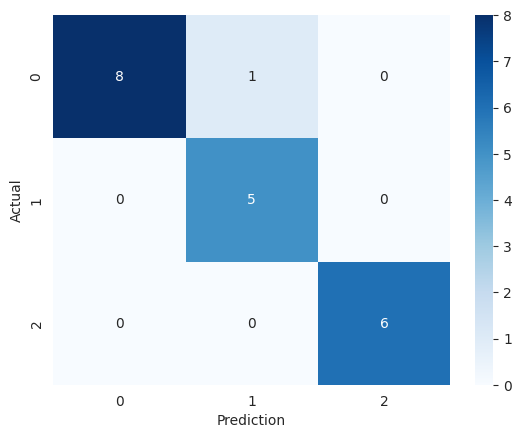

In [ ]:
import seaborn as sns

s = sns.heatmap(cf, annot = True, cmap = 'Blues')
s.set(xlabel = 'Prediction', ylabel = 'Actual')
plt.show()

> ### 정확도, 재현율, 정밀도

In [ ]:
from sklearn.metrics import *

acc = accuracy_score(y_test, y_pred)
print('accuracy_score : ', acc)
pre = precision_score(y_test, y_pred, average = 'macro') # 오탐 관점
print('precision_score : ', pre)
recall = recall_score(y_test, y_pred, average = 'macro') # 양성->양성 (미탐)
print('recall_score : ', recall)

accuracy_score :  0.95
precision_score :  0.9444444444444445
recall_score :  0.9629629629629629


- ### 결과
  - 머신러닝 분류 모델의 성능이 전반적으로 매우 우수하고 균형 잡혀있음을 의미
  - 세 가지 지표는 각각 모델예측 성능을 다른 관점에서 평가한 것

---

# 서포트 벡터 머신 (Support Vector Machine, SVM)
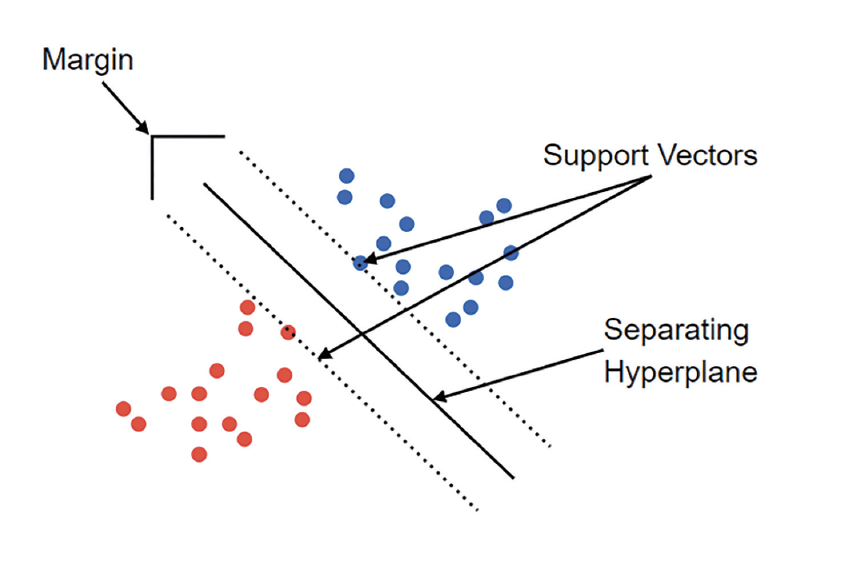

- 모델 기반 학습 (Model Based Learning) 알고리즘
- 기본적으로 두 개의 다른 클래스를 분류할 수 있는 하나의 선형식을 찾는 것이다.
- 복잡한 분류 문제에 적합하고 선형/비선형 분류가 모두 가능하다

- **Hard Margin** vs **Soft Margin**
  - 결정 경계와 서포트 벡터 사이의 거리를 Margin이라고 한다.
  - Hard Margin : 마진 안에 어떠한 데이터도 포함되지 않도록 하는 것
  - Soft Margin : 일부 데이터가 마진 내에 들어오도록 하는 것

- SVM은 데이터를 두 그룹으로 나누는 최적의 경계선(초평면)과 그 경계선에서 가장 가까운 데이터(support vector) 사이의 거리인 Margin을 최대화 하는 알고리즘

- linear/non-linear 나뉘어짐 : 이 때 RBF커널 사용

In [69]:
from sklearn import svm, datasets
cancer = datasets.load_breast_cancer()
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [70]:
dfX = pd.DataFrame(cancer.data, columns=cancer.feature_names)
dfy = pd.DataFrame(cancer.target, columns=['target'])
print('features :', dfX.shape)
print('label :', dfy.shape)

features : (569, 30)
label : (569, 1)


In [71]:
import numpy as np
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    int64  
 1   island             333 non-null    int64  
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 20.8 KB


In [72]:
df.isnull().sum(axis=0)

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dfX, dfy, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(455, 30) (114, 30)
(455, 1) (114, 1)


In [74]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
y_train = y_train.values

X_train[:3,:]

array([[-1.44075296, -0.43531947, -1.36208497, -1.1391179 ,  0.78057331,
         0.71892128,  2.82313451, -0.11914956,  1.09266219,  2.45817261,
        -0.26380039, -0.01605246, -0.47041357, -0.47476088,  0.83836493,
         3.25102691,  8.43893667,  3.39198733,  2.62116574,  2.06120787,
        -1.23286131, -0.47630949, -1.24792009, -0.97396758,  0.72289445,
         1.18673232,  4.67282796,  0.9320124 ,  2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167,  1.85197292,  1.319843  ,
         3.42627493,  2.01311199,  2.66503199,  2.1270036 ,  1.55839569,
         0.80531919, -0.81268678,  0.75195659,  0.87716951, -0.89605315,
         1.18122247,  0.18362761,  0.60059598, -0.31771686,  0.52963649,
         2.17331385,  1.3112795 ,  2.08161691,  2.1374055 ,  0.76192793,
         3.26560084,  1.92862053,  2.6989469 ,  1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, -1.10978518, -1.33264483,
        -0.30735463, -0.36555756, -0.69650228,  1

In [75]:
X_test = sc.transform(X_test)
y_test = y_test.values

In [76]:
y_train = y_train.flatten()

In [49]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(X_train, y_train)

SVC(kernel='linear')

In [50]:
X_test = sc.transform(X_test)
y_test = y_test.flatten()

y_pred=svc.predict(X_test)
y_pred

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0])

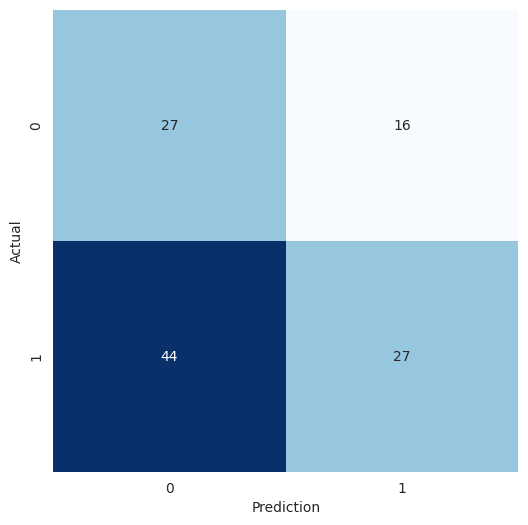

In [51]:
from sklearn.metrics import confusion_matrix

cf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))

s = sns.heatmap(cf, annot=True, fmt='d', cmap='Blues', cbar=False)
s.set(xlabel='Prediction', ylabel='Actual')
plt.show()

In [52]:
from sklearn.metrics import *

def print_scores(y_true, y_pred):
  print('accuracy_score: {0: 4f}'.format(
      accuracy_score(y_true, y_pred)))
  print('precision_score: {0: 4f}'.format(
      precision_score(y_true, y_pred)))
  print('recall_score: {0: 4f}'.format(
      recall_score(y_true, y_pred)))
print_scores(y_test,y_pred)

accuracy_score:  0.473684
precision_score:  0.627907
recall_score:  0.380282


### RBF 커널

In [77]:
svc = SVC(kernel='rbf', gamma = 0.01, C=100)
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [78]:
print_scores(y_test,y_pred)

accuracy_score:  0.956140
precision_score:  0.971429
recall_score:  0.957746


In [79]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C":[0.1,1,10,100,1000],
              'gamma':[1,0.1,0.01,0.001,0.0001],
              'kernel':['rbf']}

grid = GridSearchCV(SVC(),param_grid, refit=True,
                    cv=3, verbose=3)
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_estimator_)
print(grid.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV 1/3] END ........C=0.1, gamma=1, kernel=rbf;, score=0.632 total time=   0.0s
[CV 2/3] END ........C=0.1, gamma=1, kernel=rbf;, score=0.625 total time=   0.0s
[CV 3/3] END ........C=0.1, gamma=1, kernel=rbf;, score=0.629 total time=   0.0s
[CV 1/3] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.928 total time=   0.0s
[CV 2/3] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.928 total time=   0.0s
[CV 3/3] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.901 total time=   0.0s
[CV 1/3] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.934 total time=   0.0s
[CV 2/3] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.941 total time=   0.0s
[CV 3/3] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.927 total time=   0.0s
[CV 1/3] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.671 total time=   0.0s
[CV 2/3] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.664 total time=   0.0s
[CV 3/3] END ....C=0.1, gamma=0.001, kernel=rbf;

In [80]:
y_pred=grid.predict(X_test)
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [81]:
print_scores(y_test,y_pred)

accuracy_score:  0.973684
precision_score:  0.972222
recall_score:  0.985915


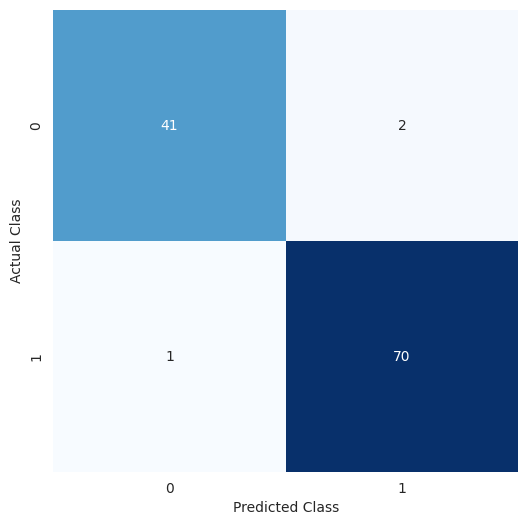

In [82]:
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
s = sns.heatmap(cf, annot=True, fmt='d', cmap="Blues", cbar=False)
s.set_ylabel('Actual Class')
s.set_xlabel('Predicted Class')
plt.show()